Using Pardiso direct solver.
Mesh built: 4,138 active cells
Sheet cells: 544 (approx volume 68,000 m^3)
Running forward simulation...
dpred shape: (110,)  (expected 110)


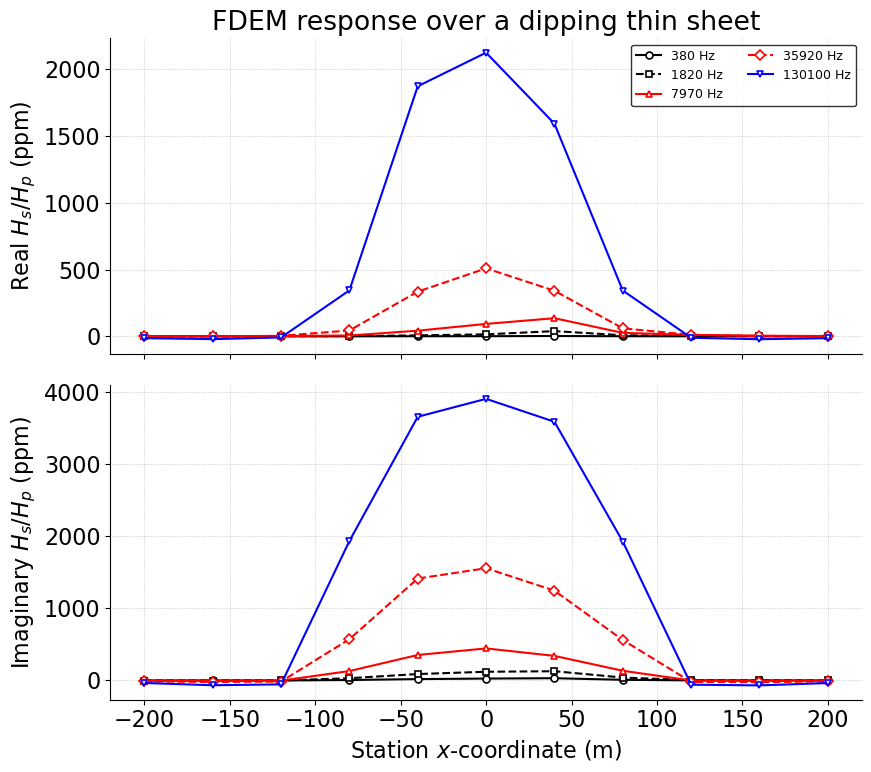

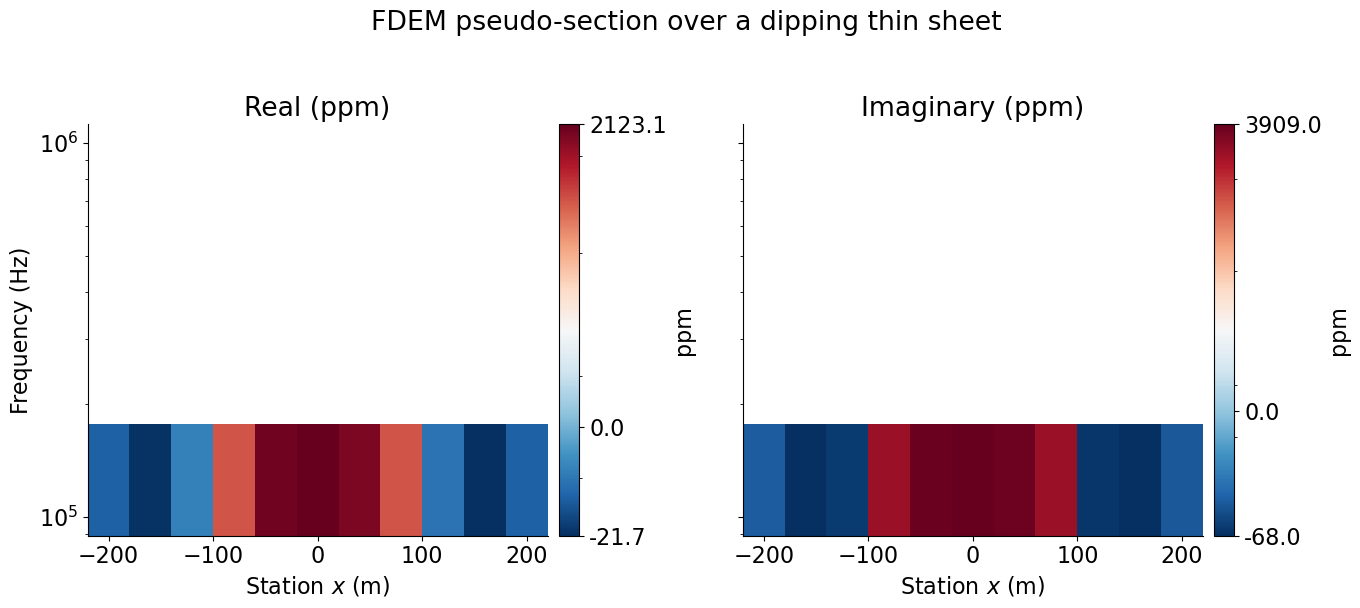

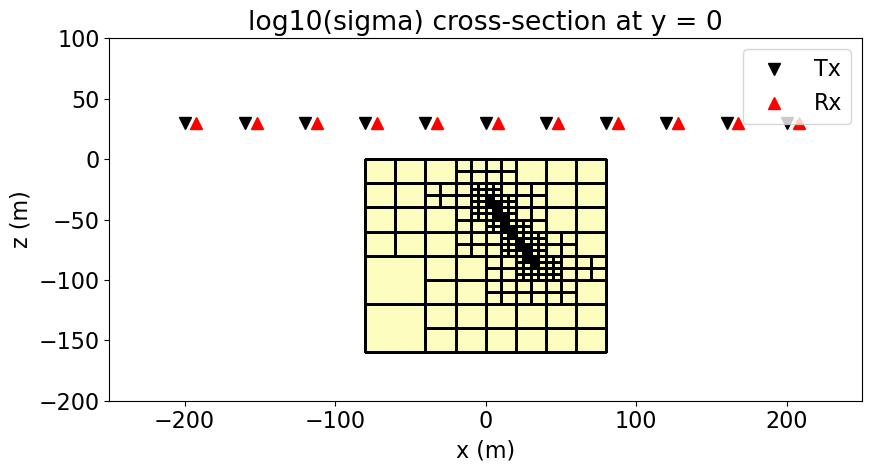

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from scipy.constants import mu_0
from discretize import TreeMesh
from SimPEG import maps
from SimPEG.electromagnetics import frequency_domain as fdem
import os
from discretize import TensorMesh
from SimPEG import maps
from SimPEG.electromagnetics import frequency_domain as fdem
from SimPEG.utils import plot_1d_layer_model
plt.rcParams.update({"font.size": 16})
try:
    from pymatsolver import Pardiso as Solver
    print("Using Pardiso direct solver.")
except ImportError:
    from SimPEG import SolverLU as Solver
    print("WARNING: Pardiso not available, falling back to SolverLU. "
          "Expect long runtimes; install pymatsolver for speed.")


frequencies = np.array([380.0, 1820.0, 7970.0, 35920.0, 130100.0])

coil_separation = 7.93
flight_height   = 30.0
n_stations = 11
x_stations = np.linspace(-200.0, 200.0, n_stations)

source_locations = np.column_stack([
    x_stations,
    np.zeros(n_stations),
    np.full(n_stations, flight_height),
])
receiver_locations = source_locations + np.array([coil_separation, 0.0, 0.0])
source_list = []
for freq in frequencies:
    for src_loc, rx_loc in zip(source_locations, receiver_locations):
        bz_real = fdem.receivers.PointMagneticFluxDensitySecondary(
            rx_loc.reshape(1, 3), orientation="z", component="real",
        )
        bz_imag = fdem.receivers.PointMagneticFluxDensitySecondary(
            rx_loc.reshape(1, 3), orientation="z", component="imag",
        )
        src = fdem.sources.MagDipole(
            receiver_list=[bz_real, bz_imag],
            frequency=freq,
            location=src_loc,
            orientation="z",
            moment=1.0,
        )
        source_list.append(src)

survey = fdem.Survey(source_list)
sheet_dip_deg       = 60.0
sheet_thickness     = 6.0
sheet_top_depth     = 30.0
sheet_dip_extent    = 70.0   
sheet_strike_extent = 300.0 
sheet_center_x      = 0.0
dip_rad = np.deg2rad(sheet_dip_deg)

dip_x, dip_z =  np.cos(dip_rad), -np.sin(dip_rad)   
n_x,   n_z   =  np.sin(dip_rad),  np.cos(dip_rad)   
p0_x,  p0_z  =  sheet_center_x,  -sheet_top_depth  
sensor_xyz = np.vstack([source_locations, receiver_locations])

dh     = 5.0      
n_base = 32      
hx = [(dh, n_base)]
hy = [(dh, n_base)]
hz = [(dh, n_base)]
mesh = TreeMesh([hx, hy, hz], origin="CCN")
max_level = int(np.log2(n_base))  

def sheet_slab_distance(x, y, z):

    perp  = (x - p0_x) * n_x   + (z - p0_z) * n_z      
    along = (x - p0_x) * dip_x + (z - p0_z) * dip_z  

    d_perp   = abs(perp)  - sheet_thickness   / 2.0
    d_along  = max(-along, along - sheet_dip_extent)
    d_strike = abs(y)     - sheet_strike_extent / 2.0

    return max(d_perp, d_along, d_strike)


def refine_function(cell):

    x, y, z = cell.center
    d_sheet = max(sheet_slab_distance(x, y, z), 0.0)
    d_sensor = float(np.min(np.linalg.norm(sensor_xyz - cell.center, axis=1)))

    d = min(d_sheet, d_sensor)

    if d <= 2.0 * dh:
        return max_level
    if d <= 6.0 * dh:
        return max_level - 1
    if d <= 14.0 * dh:
        return max_level - 2
    return 0


mesh.refine(refine_function, finalize=False)
mesh.finalize()
print(f"Mesh built: {mesh.nC:,} active cells")
sigma_background = 1e-3
sigma_air        = 1e-9
sigma_sheet      = 1.0

model = sigma_background * np.ones(mesh.nC)

cc = mesh.cell_centers
air_inds = cc[:, 2] > 0.0
model[air_inds] = sigma_air
perp_v  = (cc[:, 0] - p0_x) * n_x   + (cc[:, 2] - p0_z) * n_z
along_v = (cc[:, 0] - p0_x) * dip_x + (cc[:, 2] - p0_z) * dip_z

sheet_mask = (
      (np.abs(perp_v) <= sheet_thickness / 2.0)
    & (along_v >= 0.0) & (along_v <= sheet_dip_extent)
    & (np.abs(cc[:, 1]) <= sheet_strike_extent / 2.0)
    & (~air_inds)
)
model[sheet_mask] = sigma_sheet
print(f"Sheet cells: {sheet_mask.sum():,} "
      f"(approx volume {sheet_mask.sum() * dh**3:,.0f} m^3)")

simulation = fdem.simulation.Simulation3DMagneticFluxDensity(
    mesh,
    survey=survey,
    sigmaMap=maps.IdentityMap(mesh),
    solver=Solver,
)

print("Running forward simulation...")
dpred = simulation.dpred(model)
print(f"dpred shape: {dpred.shape}  "
      f"(expected {2 * n_stations * len(frequencies)})")

moment = 1.0
Bp_z = -mu_0 * moment / (4 * np.pi * coil_separation**3)

n_freq = len(frequencies)
data_cube     = dpred.reshape(n_freq, n_stations, 2)
data_real_ppm = (data_cube[:, :, 0] / Bp_z) * 1e6
data_imag_ppm = (data_cube[:, :, 1] / Bp_z) * 1e6

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

line_styles = [
    {"color": "black", "linestyle": "-",  "marker": "o"},
    {"color": "black", "linestyle": "--", "marker": "s"},
    {"color": "red",   "linestyle": "-",  "marker": "^"},
    {"color": "red",   "linestyle": "--", "marker": "D"},
    {"color": "blue",  "linestyle": "-",  "marker": "v"},
]

for i, f in enumerate(frequencies):
    style = line_styles[i]
    label = f"{f:.0f} Hz"
    axes[0].plot(x_stations, data_real_ppm[i],
                 color=style["color"], linestyle=style["linestyle"],
                 marker=style["marker"], label=label, lw=1.5, ms=5,
                 markerfacecolor="white", markeredgewidth=1.2)
    axes[1].plot(x_stations, data_imag_ppm[i],
                 color=style["color"], linestyle=style["linestyle"],
                 marker=style["marker"], label=label, lw=1.5, ms=5,
                 markerfacecolor="white", markeredgewidth=1.2)

axes[0].set_ylabel("Real $H_s/H_p$ (ppm)")
axes[0].set_title("FDEM response over a dipping thin sheet")
axes[0].grid(True, linestyle=":", linewidth=0.5, color="grey", alpha=0.6)
axes[0].legend(fontsize=9, ncol=2, frameon=True, edgecolor="black")

axes[1].set_ylabel("Imaginary $H_s/H_p$ (ppm)")
axes[1].set_xlabel("Station $x$-coordinate (m)")
axes[1].grid(True, linestyle=":", linewidth=0.5, color="grey", alpha=0.6)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, data, label in zip(axes,
                           [data_real_ppm, data_imag_ppm],
                           ["Real (ppm)", "Imaginary (ppm)"]):

    vmin_actual = data.min()
    vmax_actual = data.max()
    linthresh   = max(np.abs([vmin_actual, vmax_actual])) * 0.01

    im = ax.pcolormesh(
        x_stations, frequencies, data,
        norm=SymLogNorm(linthresh=linthresh,
                        vmin=vmin_actual, vmax=vmax_actual),
        cmap="RdBu_r", shading="auto",
    )
    ax.set_yscale("log")
    ax.set_xlabel("Station $x$ (m)")
    ax.set_title(label)

    cbar = plt.colorbar(im, ax=ax, label="ppm", pad=0.02)
    tick_vals = [vmin_actual, 0.0, vmax_actual]
    cbar.set_ticks(tick_vals)
    cbar.set_ticklabels([f"{v:.1f}" for v in tick_vals])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Frequency (Hz)")
plt.suptitle("FDEM pseudo-section over a dipping thin sheet", y=1.02)
plt.tight_layout()

fig, ax = plt.subplots(figsize=(9, 5))
y_slice_ind = int(mesh.h[1].size / 2)
mesh.plot_slice(
    np.log10(model), normal="Y", ind=y_slice_ind,
    ax=ax, grid=True, pcolor_opts={"cmap": "magma_r"},
)

ax.plot(source_locations[:, 0],   source_locations[:, 2],   "kv", ms=8, label="Tx")
ax.plot(receiver_locations[:, 0], receiver_locations[:, 2], "r^", ms=8, label="Rx")
ax.set_xlim(-250, 250); ax.set_ylim(-200, 100)
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
ax.set_title("log10(sigma) cross-section at y = 0")
ax.legend(loc="upper right")
plt.tight_layout()

plt.show()